In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import os
from glob import glob
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

def extract_tensorboard_scalars(logdir, output_dir, output_csv="all_runs_scalars.csv"):
    """
    Recursively scans a log directory for TensorBoard event files,
    extracts all scalar data, and saves them in one merged CSV.

    Parameters
    ----------
    logdir : str
        Path to the root directory containing TensorBoard logs.
    output_csv : str
        Path to save the merged CSV file.
    """
    all_records = []

    # Find all TensorBoard event files
    event_files = glob(os.path.join(logdir, "**/events.out.tfevents.*"), recursive=True)
    print(f"Found {len(event_files)} event files.")

    for event_file in event_files:
        try:
            ea = event_accumulator.EventAccumulator(event_file)
            ea.Reload()
        except Exception as e:
            print(f"Skipping {event_file} due to error: {e}")
            continue

        run_name = os.path.basename(os.path.dirname(event_file))

        for tag in ea.Tags().get("scalars", []):
            scalars = ea.Scalars(tag)
            for s in scalars:
                all_records.append({
                    "run": run_name,
                    "tag": tag,
                    "step": s.step,
                    "value": s.value,
                    "time": s.wall_time,
                })

    # Convert to DataFrame
    df = pd.DataFrame(all_records)

    if not df.empty:
        plot_path = os.path.join(final_dir, output_csv)

        df.to_csv(plot_path, index=False)
        print(f"✅ Exported {len(df)} rows to {plot_path}")
    else:
        print("⚠️ No scalars found in the event files.")

    return df

log_directory = "/home/clod/Desktop/THESIS_2/FULL_ATOM/RUNS/hybrid_displacement/aligned_mean_ref_bigger/"
final_dir = 'plot_data'

extract_tensorboard_scalars(log_directory, final_dir, "merged_scalars.csv")


Found 6 event files.
✅ Exported 1417 rows to plot_data/merged_scalars.csv


,run,tag,step,value,time
0,train_bonds_angles_90,Loss/train,90,0.015755,1.754315e+09
1,train_bonds_angles_90,Loss/train,91,0.015802,1.754315e+09
2,train_bonds_angles_90,Loss/train,92,0.015899,1.754316e+09
3,train_bonds_angles_90,Loss/train,93,0.015860,1.754316e+09
4,train_bonds_angles_90,Loss/train,94,0.015853,1.754316e+09
...,...,...,...,...,...
1412,train_0,Learning Rate,25,0.000100,1.754310e+09
1413,train_0,Learning Rate,26,0.000100,1.754311e+09
1414,train_0,Learning Rate,27,0.000100,1.754311e+09
1415,train_0,Learning Rate,28,0.000100,1.754311e+09


In [18]:
df = pd.read_csv('/home/clod/Desktop/THESIS_2/FULL_ATOM/CODES/plot_data/merged_scalars.csv')

df.drop(columns=['time'], inplace=True)
max_epochs = df['step'].max()
print(f"Max epochs: {max_epochs}")

# substitute tag column with a separate column for each tag
df_pivot = df.pivot_table(index=['run', 'step'], columns='tag', values='value')

df_pivot[0:10]

Max epochs: 119


tag              Beta  Lambda  Learning Rate  Loss/KL_train  Loss/KL_val  \
run     step                                                               
train_0 0     0.00001     NaN         0.0001      25.052250     8.495078   
        1     0.00001     NaN         0.0001       4.926425     3.853768   
        2     0.00001     NaN         0.0001       9.332728     3.523996   
        3     0.00001     NaN         0.0001       0.970852     0.542138   
        4     0.00001     NaN         0.0001       7.097167     3.569149   
        5     0.00001     NaN         0.0001       2.258932     0.558461   
        6     0.00001     NaN         0.0001       0.216254     0.059184   
        7     0.00001     NaN         0.0001       0.040271     0.034516   
        8     0.00001     NaN         0.0001       0.144509     0.108722   
        9     0.00001     NaN         0.0001       0.147634     0.035427   

tag           Loss/Physics_train  Loss/Physics_val  Loss/Reconstruction_train  \
run     step                                                                    
train_0 0                    NaN               NaN                   0.017928   
        1                    NaN               NaN                   0.017018   
        2                    NaN               NaN                   0.016963   
        3                    NaN               NaN                   0.016277   
        4                    NaN               NaN                   0.016717   
        5                    NaN               NaN                   0.016240   
        6                    NaN               NaN                   0.015902   
        7                    NaN               NaN                   0.015782   
        8                    NaN               NaN                   0.015816   
        9                    NaN               NaN                   0.015804   

tag           Loss/Reconstruction_val  Loss/train  Loss/val  
run     step                                                 
train_0 0                    0.017474    0.018178  0.017559  
        1                    0.017459    0.017068  0.017497  
        2                    0.016758    0.017056  0.016793  
        3                    0.017031    0.016287  0.017037  
        4                    0.016993    0.016788  0.017029  
        5                    0.016477    0.016263  0.016483  
        6                    0.016185    0.015904  0.016185  
        7                    0.016168    0.015782  0.016168  
        8                    0.016259    0.015818  0.016260  
        9                    0.016071    0.015805  0.016072

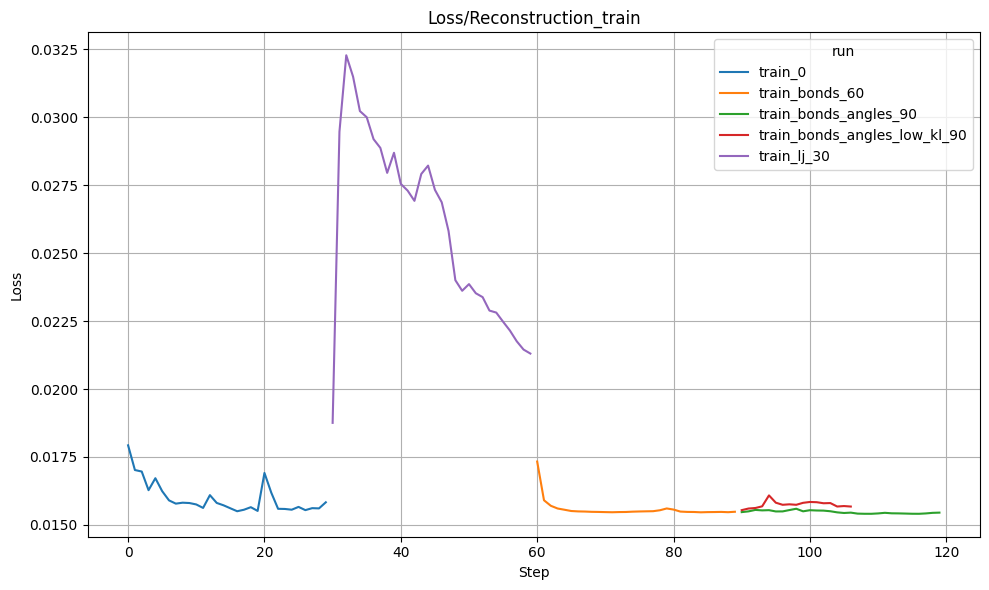

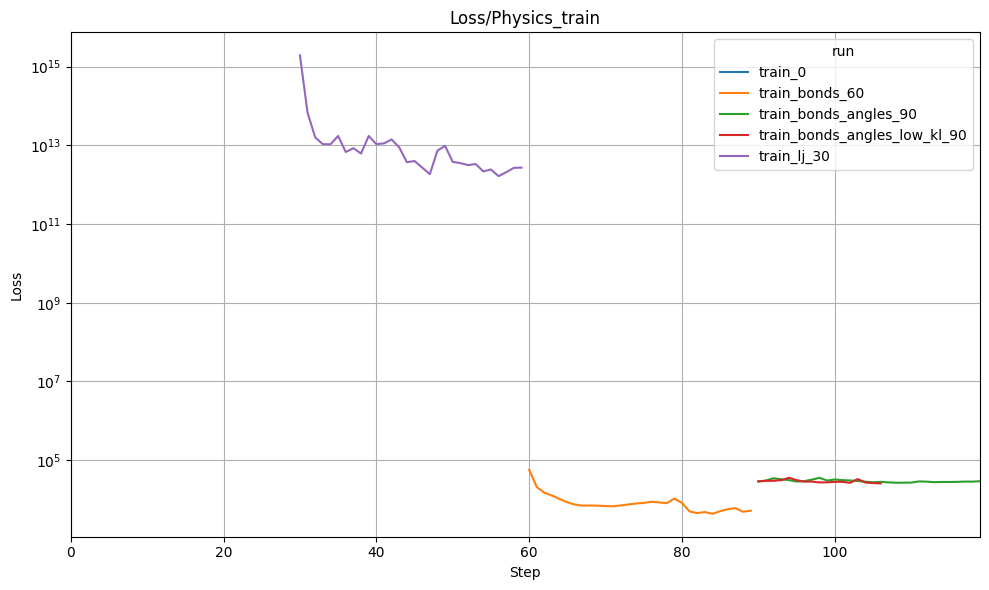

In [20]:
y_var = "Loss/Reconstruction_train"
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pivot, x='step', y=y_var, hue='run')
plt.title(y_var)
plt.xlabel('Step')
plt.ylabel('Loss')
#plt.legend(title='Run', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

y_var = "Loss/Physics_train"
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pivot, x='step', y=y_var, hue='run')
plt.title(y_var)
plt.xlabel('Step')
plt.yscale('log')
plt.ylabel('Loss')
plt.xlim(0,max_epochs)
#plt.legend(title='Run', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()